# Initial Imports and Constants

In [182]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os
import math

In [104]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [105]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [106]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [107]:
TOI_id = 'TOI 1339'
search_result = lk.search_lightcurve(TOI_id, author='SPOC')
print(search_result)


SearchResult containing 47 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 15 2019   SPOC     120   269701147      0.0
  1 TESS Sector 16 2019   SPOC     120   269701147      0.0
  2 TESS Sector 17 2019   SPOC     120   269701147      0.0
  3 TESS Sector 18 2019   SPOC     120   269701147      0.0
  4 TESS Sector 19 2019   SPOC     120   269701147      0.0
  5 TESS Sector 21 2020   SPOC     120   269701147      0.0
  6 TESS Sector 22 2020   SPOC     120   269701147      0.0
  7 TESS Sector 24 2020   SPOC     120   269701147      0.0
  8 TESS Sector 25 2020   SPOC     120   269701147      0.0
...            ...  ...    ...     ...         ...      ...
 37 TESS Sector 86 2024   SPOC      20   269701147      0.0
 38 TESS Sector 78 2024   SPOC     120   269701147      0.0
 39 TESS Sector 76 2024   SPOC     120   269701147      0

In [108]:
lc_collection = search_result.download_all()
print(lc_collection)

LightCurveCollection of 47 objects:
    0: <TessLightCurve LABEL="TIC 269701147" SECTOR=15 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 269701147" SECTOR=16 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 269701147" SECTOR=17 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 269701147" SECTOR=18 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 269701147" SECTOR=19 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 269701147" SECTOR=21 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 269701147" SECTOR=22 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    7: <TessLightCurve LABEL="TIC 269701147" SECTOR=24 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    8: <TessLightCurve LABEL="TIC 269701147" SECTOR=25 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    9: <TessLightCurve LABEL="TIC 269701147" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    10: <TessLightCurve LABEL="TIC 269701147

In [372]:
### mask transits out before normalizing and removing outliers 
if mask_transits == True:
    ### mask transit times before flattening
    transit_times1_120 = [1715.354746482542, 1733.115369534969, 1741.996345354458, 1759.758819060445, 
                          1786.3986654179103, 1795.2831459740814, 1804.1592033060992, 1813.0392831314516, 
                          1821.9180145080772, 1830.8017387539828, 1839.6804898115759, 1875.2014897815563, 
                          1892.9628647808674, 1901.843275813667, 1910.7223686858317, 1919.6014862983075, 
                          1964.003725469874, 1972.8840175983191, 1981.7646658445788, 1990.644612114476, 
                          1999.524639406961, 2008.4052942751948, 2425.7826938851645, 2434.6627506979466, 
                          2443.542455620913, 2612.2662638526494, 2621.150658695988, 2630.0280519404414, 
                          2647.789592040927, 2656.669673413452, 2701.07335988083, 2718.832273895279, 
                          2727.7109563935223, 2736.5923796134493, 2798.753896465541, 2807.6346091497285, 
                          2816.5149086624456, 2825.396246422208, 2834.2782280828546, 2843.1567921247233, 
                          2852.0360595551683, 2914.195996437057, 2923.0777268631805, 2931.9570406091407, 
                          2940.8440758911756, 2949.7211045589625, 2958.601791561051, 3296.0512996511125, 
                          3340.4540517320133, 3349.3337618516202, 3358.2141007437344, 3367.096528308062, 
                          3375.976348274385, 3384.855758190766, 3393.73881858342, 3402.6170508730675, 
                          3420.37372878859, 3438.1405935487614, 3447.019189674554, 3455.898868469713, 
                          3464.7799101830874, 3473.6618975064807, 3535.8221842448133, 3544.6994958429154, 
                          3553.5818340529354, 3562.4634851892574, 3571.3440690158545, 3580.222328354312, 
                          3615.745064261839, 3660.1447093186034]
    transit_times2_120 = [1726.0543073746499, 1754.634043965897, 1783.2115328271677, 1811.799709252357, 
                          1840.375325305024, 1897.535580205685, 1926.1164468441034, 2440.5464000264496, 
                          2612.028543417274, 2697.771827053584, 2726.351987285226, 2812.0954555257877, 
                          2840.6723275065156, 2926.4215475832184, 3297.9726631034496, 3355.130554203686, 
                          3383.7103874786258, 3440.8754011789956, 3555.19503141751, 3583.7721295971896, 
                          3640.9330744268664]
    transit_times3_120 = [1743.5522822268827, 1781.9030676559116, 1820.2655396847936, 1896.96100510817, 
                          1973.6640664787449, 2433.9156496340456, 2664.024879204517, 2702.3548744476616, 
                          2740.7164183232103, 2817.4104839147385, 2932.462260903496, 3354.3029929461736, 
                          3392.6619207076765, 3546.072794556178, 3622.7679361489895, 3661.1260225588803]
    # transit_times1_20 = [2425.781671135145, 2434.6624703174352, 2443.5423796109203, 2612.2684481713577, 
    #                      2621.1510454117415, 2630.0275398575673, 2647.7900538979006, 2656.669726531292, 
    #                      2701.0725414166154, 2718.8323542612056, 2727.710907504246, 2736.5922493638554, 
    #                      2798.7545420305955, 2807.6356634491485, 2816.514655391101, 2825.395530143617, 
    #                      2834.277484692579, 2843.156974635499, 2852.0384484248025, 2914.197384150204, 
    #                      2923.0778820870382, 2931.9571207364143, 2940.839689041113, 2958.6015109188284, 
    #                      3296.051121211378, 3340.4532059302223, 3349.3343529494396, 3358.2128462226856, 
    #                      3367.10014952418, 3375.9753461665846, 3384.8550146672706, 3393.7383879034232, 
    #                      3420.3769893786307, 3438.136540591031, 3447.0192700680527, 3455.8988195587076, 
    #                      3464.7791668472623, 3473.662182303581, 3535.821570188835, 3544.700577259685, 
    #                      3553.582118804313, 3562.4637427893786, 3571.3442515432093, 3580.222381562287, 
    #                      3615.7453217433413, 3633.5065285943206, 3660.1447894582507]
    # transit_times2_20 = [2440.5453772579517, 2612.0257498217884, 2640.607360037848, 2697.772009576271, 
    #                      2726.3527350293425, 2812.097640098747, 2840.6726872691265, 2926.4182639328533, 
    #                      3297.970203178181, 3355.1306343302267, 3383.7110057186396, 3440.8761217520487, 
    #                      3555.194805258147, 3583.7676407579665, 3612.3498560606936, 3640.9332567617016]
    # transit_times3_20 = [2433.9165746177628, 2664.0253139879796, 2702.3527963863708, 2740.71821502839, 
    #                      2817.4108437379555, 2932.462313935031, 3354.303508928905, 3392.6595088877752, 
    #                      3546.0728478211595, 3622.7703249199426, 3661.1276146501823]

    
    T14_1= 2.939 * 0.0416667 
    T14_2= 4.162 * 0.0416667 
    T14_3= 5.36 * 0.0416667
    
    masked_lc = lc_collection.stitch()

    times = masked_lc.time.value

    ### Initialize a mask with all False values (i.e., include all data points initially)
    mask = np.zeros_like(times, dtype=bool)

    ### Iterate through each transit time and update the mask
    for transit_time in transit_times1_120:
        mask |= (times > (transit_time - (T14_1/2)*1.5)) & (times < (transit_time + (T14_1/2)*1.5))
    # for transit_time in transit_times1_20:
    #     mask |= (times > (transit_time - (T14_1/2)*1.5)) & (times < (transit_time + (T14_1/2)*1.5))

    for transit_time in transit_times2_120:
        mask |= (times > (transit_time - (T14_2/2)*1.5)) & (times < (transit_time + (T14_2/2)*1.5))
    # for transit_time in transit_times2_20:
    #     mask |= (times > (transit_time - (T14_2/2)*1.5)) & (times < (transit_time + (T14_2/2)*1.5))

    for transit_time in transit_times3_120:
        mask |= (times > (transit_time - (T14_3/2)*1.5)) & (times < (transit_time + (T14_3/2)*1.5))
    # for transit_time in transit_times3_20:
    #     mask |= (times > (transit_time - (T14_3/2)*1.5)) & (times < (transit_time + (T14_3/2)*1.5))

    ### Flatten the masked light curve
    masked_lc = masked_lc.flatten(window_length=1901, mask=mask).remove_outliers()
    combined_lc = masked_lc
else:
    ### flatten unmasked lightcurve 
    combined_lc = lc.flatten(window_length=1901).remove_outliers()

# combined_lc.plot()
# plt.show()

In [373]:
# clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [374]:
# # Normalize, flatten, and remove outliers
# processed_lcs = [
#     lc.normalize().flatten(window_length=401).remove_outliers(sigma=5)
#     for lc in clean_lcs
# ]

In [375]:
# # Stitch into one combined light curve
# combined_lc = processed_lcs[0]
# for lc in processed_lcs[1:]:
#     combined_lc = combined_lc.append(lc)



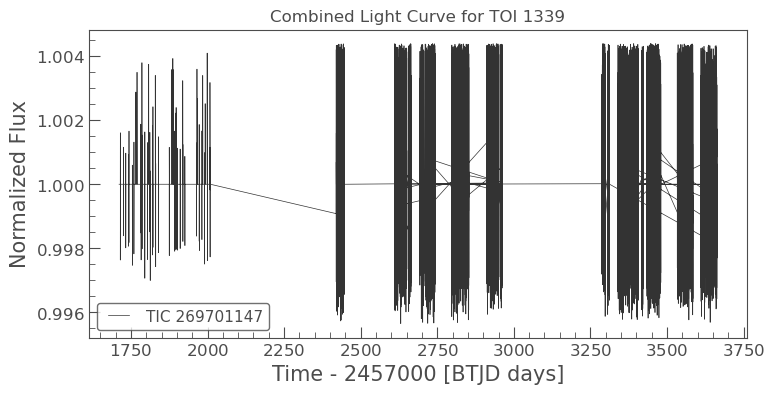

In [376]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [377]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1711.36577373 1711.36716265 1711.36855156 ... 3662.82380309 3662.82519195
 3662.82658081]
[1. 1. 1. ... 1. 1. 1.]


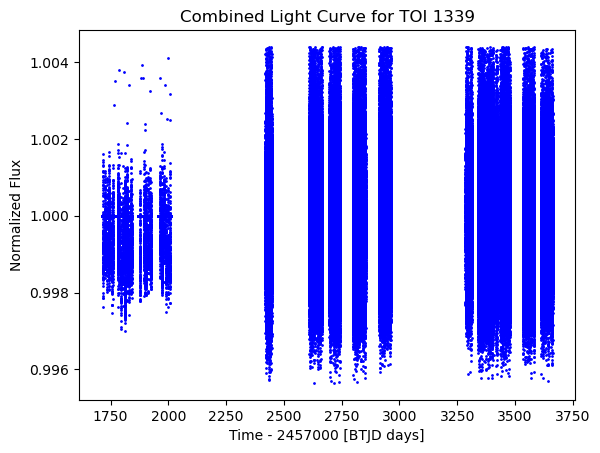

In [378]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

`period` contains 147250 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


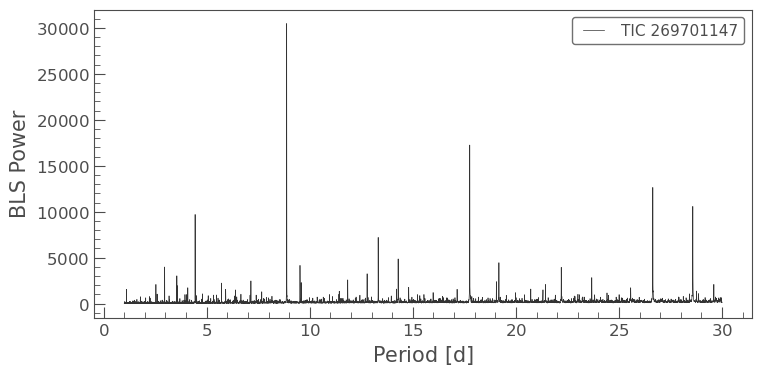

In [116]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1, 30, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [117]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")
print(f"Best candidate dur: {planet_1_dur.value:.5f} days")

Best candidate period: 8.88009 days
Best candidate t0: 1715.39077 days
Best candidate dur: 0.10000 days


In [118]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*1.5)

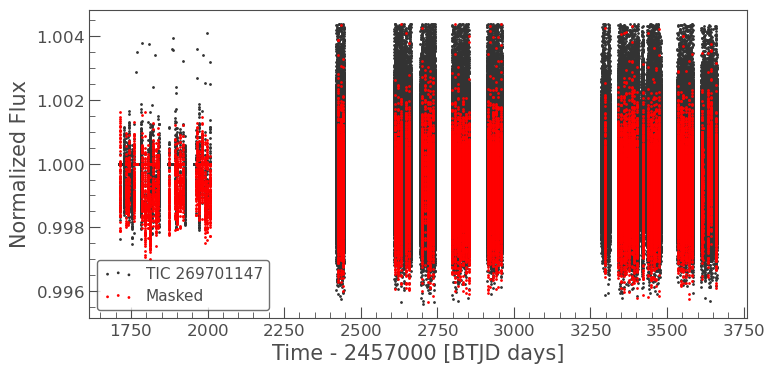

In [119]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [120]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


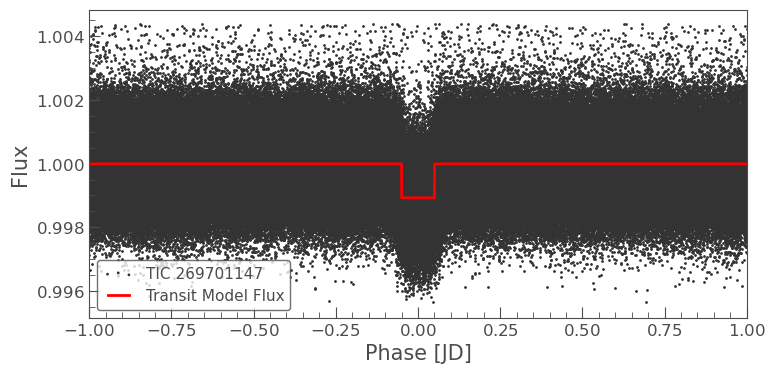

In [121]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


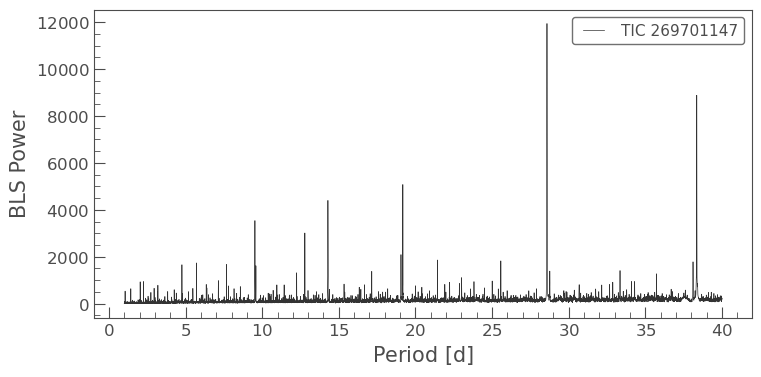

In [122]:
period = np.linspace(1, 40, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [123]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 28.57966 days
Best candidate t0 2: 1726.08077 days


In [124]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [125]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*1.5)

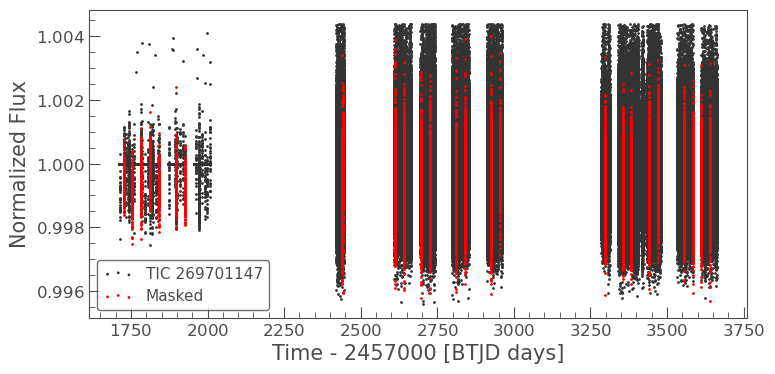

In [126]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [127]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

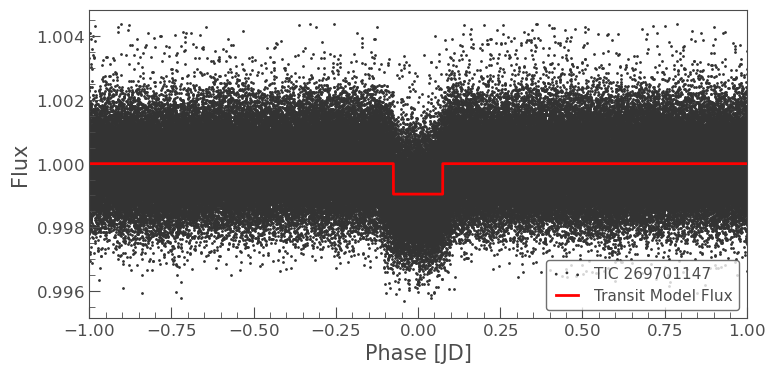

In [128]:
ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 3

`period` contains 148519 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


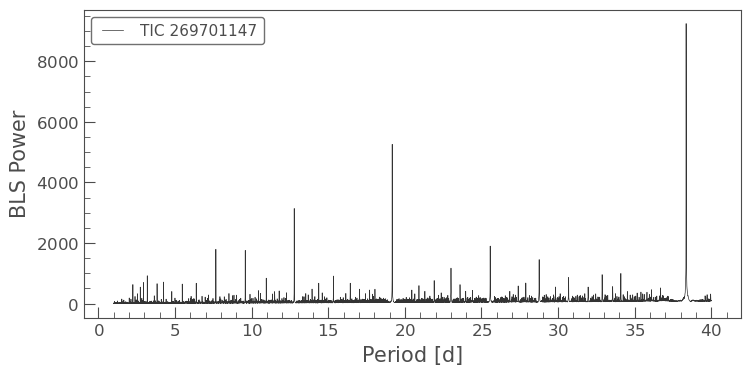

In [129]:
period = np.linspace(1, 40, 10000)
bls_3 = masked_lc_2.to_periodogram('bls', period=period, frequency_factor=500)
bls_3.plot()
plt.show()

In [130]:
planet_3_period = bls_3.period_at_max_power
planet_3_t0 = bls_3.transit_time_at_max_power
planet_3_dur = bls_3.duration_at_max_power

print(f"Best candidate period 3: {planet_3_period.value:.5f} days")
print(f"Best candidate t0 3: {planet_3_t0.value:.5f} days")

Best candidate period 3: 38.35014 days
Best candidate t0 3: 1743.60577 days


In [131]:
planet_3_mask = bls_3.get_transit_mask(period=planet_3_period,
                                     transit_time=planet_3_t0,
                                     duration=planet_3_dur*2.5)

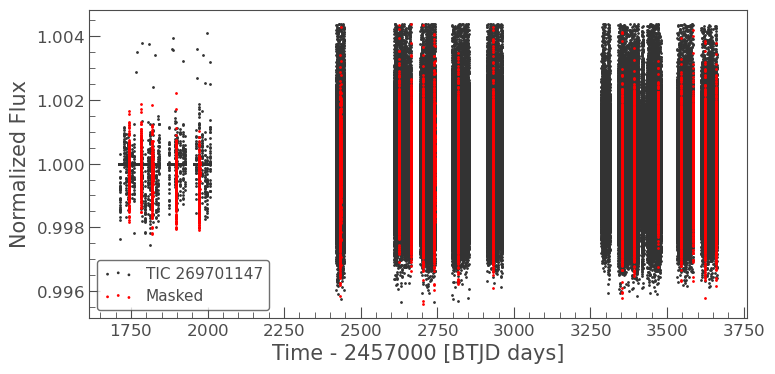

In [132]:
masked_lc_3 = masked_lc_2[~planet_3_mask]
ax = masked_lc_3.scatter();
masked_lc_2[planet_3_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [133]:
planet_3_model = bls_3.get_transit_model(period=planet_3_period,
                                       transit_time=planet_3_t0,
                                       duration=planet_3_dur)

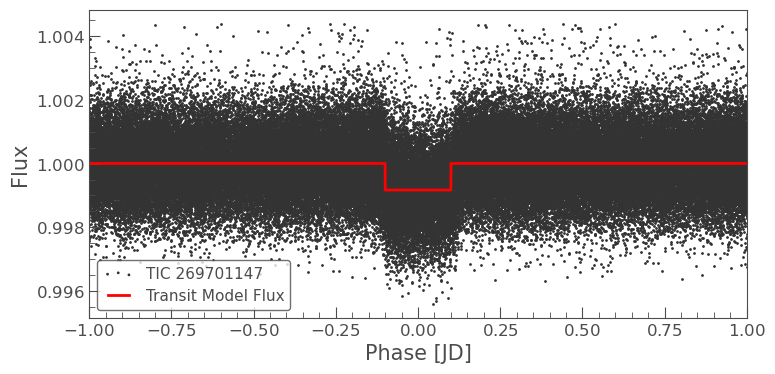

In [134]:
ax = masked_lc_2.fold(planet_3_period, planet_3_t0).scatter()
planet_3_model.fold(planet_3_period, planet_3_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## Transit models

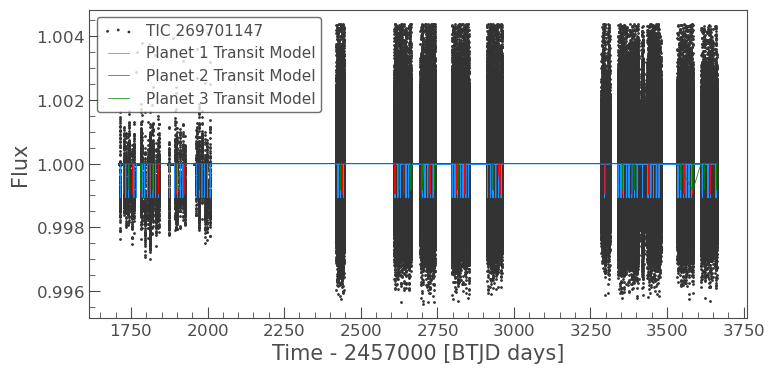

In [135]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');
# planet_4_model.plot(ax=ax, c='purple', label='Planet 4 Transit Model');
# planet_5_model.plot(ax=ax, c='orange', label='Planet 5? Transit Model');
# planet_6_model.plot(ax=ax, c='pink', label='Planet 6 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

## Finding transit guess times based on models 

In [312]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = np.sort(planet_1_model.time.value[peaks_1])
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[1715.38944376 1733.15078837 1742.0300416  1759.78984595 1768.67178277
 1786.43280369 1795.31050246 1804.19095166 1813.07136515 1821.95176484
 1830.83076354 1839.71251761 1875.2311819  1892.99194378 1901.87235482
 1910.75139352 1919.6318458  1964.03452717 1972.91376407 1981.79441236
 1990.67230238 1999.55438592 2008.43231724 2425.79709173 2425.79790193
 2434.67770012 2434.67781586 2443.55713288 2443.55794308 2612.27932681
 2612.27944255 2621.15960192 2621.15971766 2630.03872505 2630.0397667
 2647.79959784 2647.79994506 2656.67995136 2656.6800671  2701.08008332
 2701.08043055 2709.96072287 2710.00204277 2718.83999835 2718.84057706
 2727.72068288 2727.72079863 2736.59999562 2736.60080582 2798.76095362
 2798.76153233 2807.64027739 2807.64155056 2816.5209648  2816.52154351
 2825.4016352  2825.40175094 2834.28089329 2834.28170348 2843.16151354
 2843.16209225 2852.04072674 2852.04199989 2914.20133086 2914.20260399
 2923.08172661 2923.08253678 2931.96209

In [313]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = np.sort(planet_2_model.time.value[peaks_2])
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[1726.0798789  1754.65928174 1783.23977351 1811.81860717 1840.39861505
 1897.55853635 1926.13734687 2440.57097061 2440.57201229 2612.05004908
 2612.05016482 2640.62988879 2697.78838953 2697.78896823 2726.36788251
 2726.36869271 2812.10701305 2812.10759176 2840.68650006 2840.68731025
 2926.42609776 2926.42621349 2955.06077515 2955.06158532 3297.96180305
 3297.96191878 3355.12042303 3355.1212332  3383.70059006 3383.7007058
 3440.85993161 3440.86004736 3469.4395237  3469.44010241 3555.17861513
 3555.17873087 3583.75799465 3583.75857336 3612.33811928 3640.91727093
 3640.91784962]


In [314]:
# Find all local minima (i.e., transit dips)
peaks_3, _ = find_peaks(-planet_3_model.flux.value, prominence=1e-5)
transit_times_3 = np.sort(planet_3_model.time.value[peaks_3])
fluxes_3 = planet_3_model.flux.value[peaks_3]

print("Planet 3 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_3)

Planet 3 transit dip times and depths:
[1743.60505174 1781.95645021 1820.30596336 1897.00715535 1973.70543708
 2433.90697018 2433.90801186 2625.65882173 2664.00780377 2664.00907691
 2702.35787332 2702.35914648 2740.70840622 2740.70921642 2817.4084778
 2817.40975096 2932.45930783 2932.45965505 3354.31071723 3354.31152739
 3392.66024818 3392.66152132 3469.29449815 3469.29507686 3546.06183365
 3546.0619494  3584.34410804 3584.34445526 3622.76198013 3622.76232735
 3661.11133695 3661.11261007]


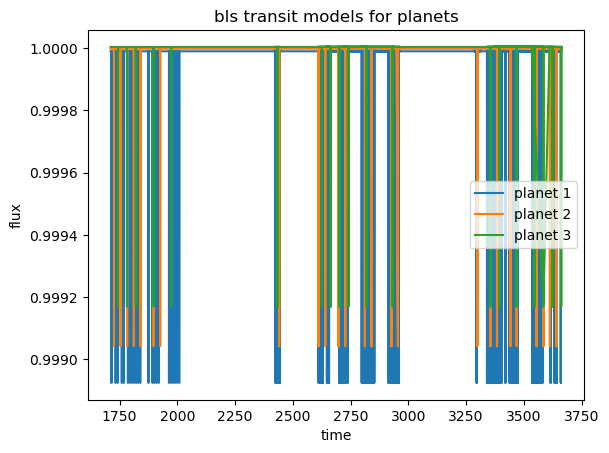

In [315]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')
# plt.plot(planet_4_model.time.value, planet_4_model.flux.value, label='planet 4')
# plt.plot(planet_5_model.time.value, planet_5_model.flux.value, label='planet 5?')
# plt.plot(planet_6_model.time.value, planet_6_model.flux.value, label='planet 6?')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1377,1380)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [316]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [317]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [318]:

def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        # ### fit parabola to the chisq
        # p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        # ### Extract the coefficients   y = ax^2 + bx + c
        # a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        # ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        # tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        # ### Calculate the minimum chi-squared value
        # chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        # tc_chi_parabola[j] = tc_best_fit
    
        # ### Calculate the parabola best fit 
        # p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        # ### calculate ttv from parabola fit 
        # ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        # err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # Find the intersection using root_scalar
        intersections = []
        for k in range(len(tc1) - 1):
            if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
                sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
                if sol.converged:
                    intersections.append((sol.root - min_chi_time))
        errors.append(intersections)

        # errors = np.array(errors)

        # ### avg the errors
        # sig = np.sqrt(errors[0]**2 + errors[1]**2)
        # err_tc_chi.append(sig)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv, errors

In [319]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [320]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [321]:
### stellar params
q1 = 0.304
q2 = 0.40

u1 = 2 * np.sqrt(q1) * q2
u2 = np.sqrt(q1) * (1 - 2 * q2)
print(u1)
print(u2)

0.44108956006688715
0.11027239001672175


## Planet 1

In [322]:
### Planet params (from exoplanet archive Gilbert et al 2023)
# planet b
per_1=  8.8803232 #8.8803256
rp_1= 0.0333265970068500 #0.03319
b_1=  0.522936735232103 #0.610
T14_1= 3.06623299086887 * 0.0416667  #2.939 * 0.0416667  # convert to days from hours 


In [323]:
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [324]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []
err_tc_chi = []

In [325]:
tc_chi_1, ttv_1, tc_err1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [326]:
print(tc_chi_1)

[1715.32654748 1733.11658748 1741.99784271 1759.75798072 1768.50511597
 1786.39760179 1795.27930458 1804.16108844 1813.04517227 1821.91756395
 1830.80056665 1839.67965138 1875.20198602 1892.96341523 1901.84482727
 1910.72286497 1919.60198258 1963.99865793 1972.89324354 1981.76421547
 1990.64477483 1999.52318803 2008.4291474  2425.7815762  2425.78171907
 2434.66285192 2434.66296767 2443.54228468 2443.54242755 2612.26848262
 2612.26859836 2621.15075974 2621.15087548 2630.02788087 2630.02792152
 2647.79008833 2647.79010188 2656.67010818 2656.66989025 2701.07257581
 2701.07258937 2709.79405607 2709.83537597 2718.83215717 2718.83206854
 2727.7108397  2727.71095544 2736.5924881  2736.5922973  2798.75411344
 2798.75402482 2807.63543922 2807.63537772 2816.51479196 2816.51470333
 2825.39579602 2825.39591176 2834.27805712 2834.27786631 2843.15667537
 2843.15658674 2852.0375569  2852.03749538 2914.19682636 2914.19676481
 2923.07755577 2923.07769861 2931.95692371 2931.95716873 2940.84128964
 2940.

In [327]:
### after inspection of single transits
values_to_remove_1 = [1768.5051159705383, 2709.7940560715215, 3642.20057877844]
# Define a tolerance level (adjust if needed)
tolerance = 1e-1

# tc_chi_1 = [x for x in tc_chi_1 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_1)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_1_cleaned = []
ttv_1_cleaned = []
tc_err_1_cleaned = []

for i in range(len(tc_chi_1)):
    if not any(math.isclose(tc_chi_1[i], val, abs_tol=tolerance) for val in values_to_remove_1):
        tc_chi_1_cleaned.append(tc_chi_1[i])
        ttv_1_cleaned.append(ttv_1[i])
        tc_err_1_cleaned.append(tc_err1[i])

# Overwrite the originals if needed
tc_chi_1 = tc_chi_1_cleaned
ttv_1 = ttv_1_cleaned
tc_err1 = tc_err_1_cleaned
print("Modified List (after removal):", tc_chi_1)
# print(tc_err1)


Modified List (after removal): [1715.3265474840546, 1733.116587475448, 1741.9978427100987, 1759.7579807246095, 1786.3976017933537, 1795.2793045754488, 1804.1610884360182, 1813.0451722678217, 1821.9175639453665, 1830.8005666535673, 1839.6796513849463, 1875.2019860170062, 1892.9634152284386, 1901.844827268381, 1910.722864965265, 1919.6019825806522, 1963.9986579341933, 1972.8932435370923, 1981.7642154683404, 1990.6447748325165, 1999.5231880340461, 2008.4291473959863, 2425.781576203251, 2425.781719069658, 2434.662851924453, 2434.6629676670577, 2443.542284684583, 2443.5424275490977, 2612.268482622415, 2612.2685983608344, 2621.150759738923, 2621.1508754776346, 2630.0278808675125, 2630.027921516082, 2647.7900883278357, 2647.790101879494, 2656.670108177125, 2656.669890249615, 2701.072575809435, 2701.072589367608, 2718.832157167069, 2718.8320685424906, 2727.7108397000043, 2727.710955442671, 2736.5924881027977, 2736.592297300766, 2798.754113437948, 2798.7540248168084, 2807.635439217513, 2807.635

In [328]:
tc_err_1 = []
for i in range(len(tc_err1)):
    if len(tc_err1[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err1[i][0]**2 + tc_err1[i][1]**2)
        tc_err_1.append(sig)
    else:
        print(f"Unexpected format in tc_err1[{i}]: {tc_err1[i]}, {tc_chi_1[i]}")

# print(tc_err_1)

In [329]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi_1

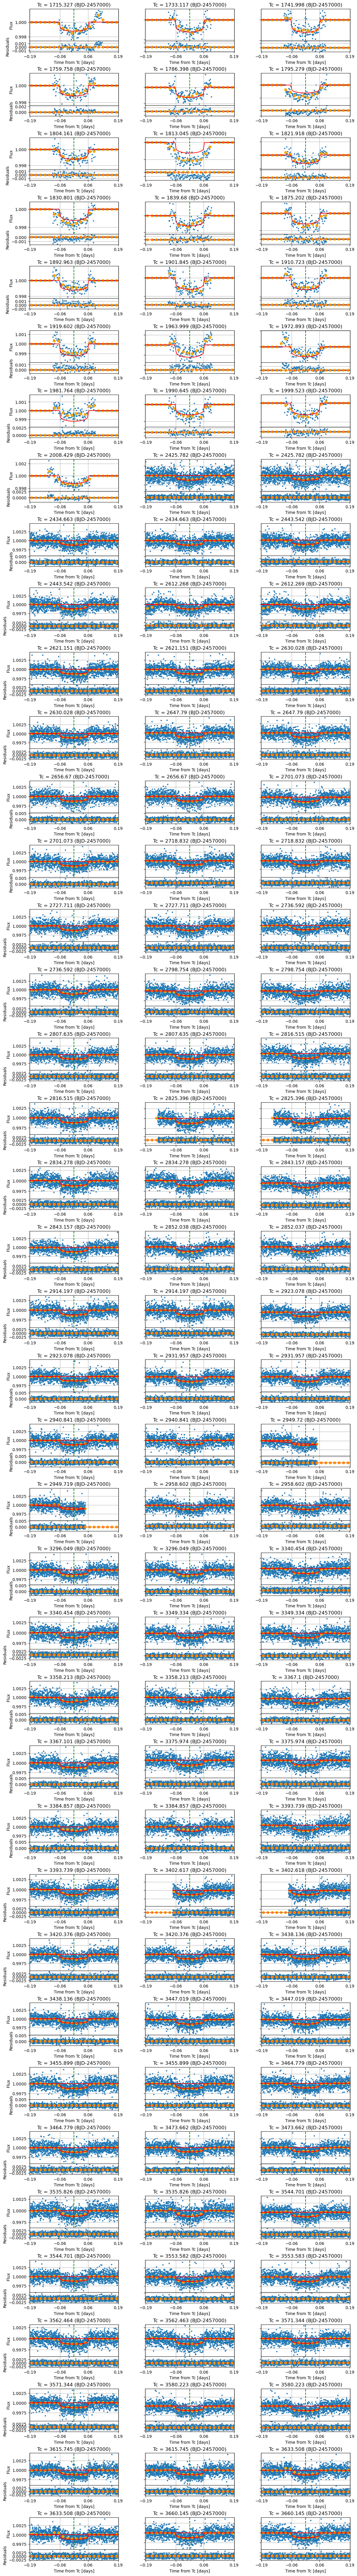

In [330]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

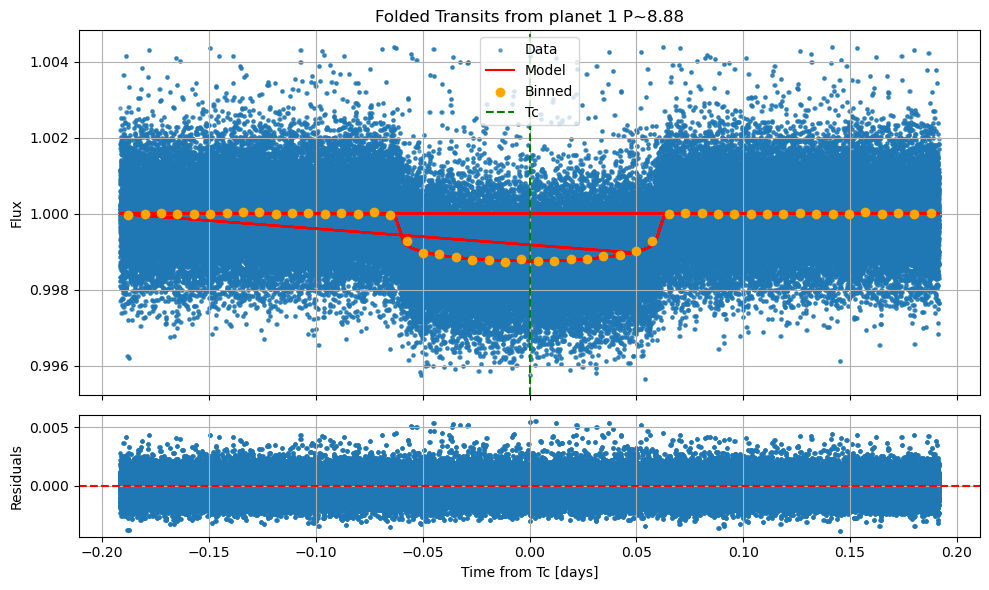

In [331]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 1 P~{round(planet_1_period.value, 3)}')

## Planet 2

In [332]:
### Planet params (from barros et al 2022)
per_2=  28.579889 #28.579743
rp_2= 0.0312382795966642 #0.03118
b_2=  0.482378819760311 #0.630
T14_2= 4.47016349523855 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 


In [333]:
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [334]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []
err_tc_chi = []

In [335]:
tc_chi_2, ttv_2, tc_err2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [336]:
print(tc_chi_2)

[1726.0813804  1754.63642553 1783.20924295 1811.79908763 1840.37776085
 1897.53234347 1926.118161   2440.5461124  2440.54615308 2612.0258582
 2612.02597394 2640.60636525 2697.77153933 2697.77178437 2726.35236698
 2726.35250985 2812.09750353 2812.09741491 2840.67265287 2840.67279572
 2926.41959124 2926.41970698 2954.94782878 2954.94797161 3297.97131256
 3297.9714283  3355.13059988 3355.13040905 3383.71009957 3383.71021531
 3440.87611448 3440.87623022 3469.2728569  3469.27343561 3555.195799
 3555.19558107 3583.77184185 3583.77175322 3612.3496308  3640.93211912
 3640.93236415]


In [337]:
### after inspection of single transits
values_to_remove_2 = [2954.9979589823915, 3469.42362847]
# Define a tolerance level (adjust if needed)
tolerance = 1

# tc_chi_2 = [x for x in tc_chi_2 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_2)]
# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_2_cleaned = []
ttv_2_cleaned = []
tc_err_2_cleaned = []

for i in range(len(tc_chi_2)):
    if not any(math.isclose(tc_chi_2[i], val, abs_tol=tolerance) for val in values_to_remove_2):
        tc_chi_2_cleaned.append(tc_chi_2[i])
        ttv_2_cleaned.append(ttv_2[i])
        tc_err_2_cleaned.append(tc_err2[i])

# Overwrite the originals if needed
tc_chi_2 = tc_chi_2_cleaned
ttv_2 = ttv_2_cleaned
tc_err2 = tc_err_2_cleaned
print("Modified List (after removal):", tc_chi_2)


Modified List (after removal): [1726.0813804047416, 1754.6364255277294, 1783.2092429510228, 1811.799087633854, 1840.3777608498626, 1897.532343469774, 1926.118161000506, 2440.5461123969703, 2440.54615307966, 2612.0258582045503, 2612.025973942911, 2640.6063652486214, 2697.771539328083, 2697.7717843686783, 2726.3523669833344, 2726.35250984729, 2812.0975035315178, 2812.0974149085164, 2840.672652868266, 2840.6727957230823, 2926.419591244132, 2926.419706982432, 3297.9713125636968, 3297.9714283021144, 3355.1305998796797, 3355.1304090467825, 3383.7100995744977, 3383.7102153139012, 3440.876114475843, 3440.8762302176924, 3555.195798995175, 3555.195581070223, 3583.7718418456557, 3583.7717532174597, 3612.3496308034983, 3640.932119124067, 3640.9323641502215]


In [338]:
tc_err_2 = []
for i in range(len(tc_err2)):
    if len(tc_err2[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err2[i][0]**2 + tc_err2[i][1]**2)
        tc_err_2.append(sig)
    else:
        print(f"Unexpected format in tc_err2[{i}]: {tc_err2[i]}, {tc_chi_2[i]}")

# print(tc_err_2)

In [339]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi_2

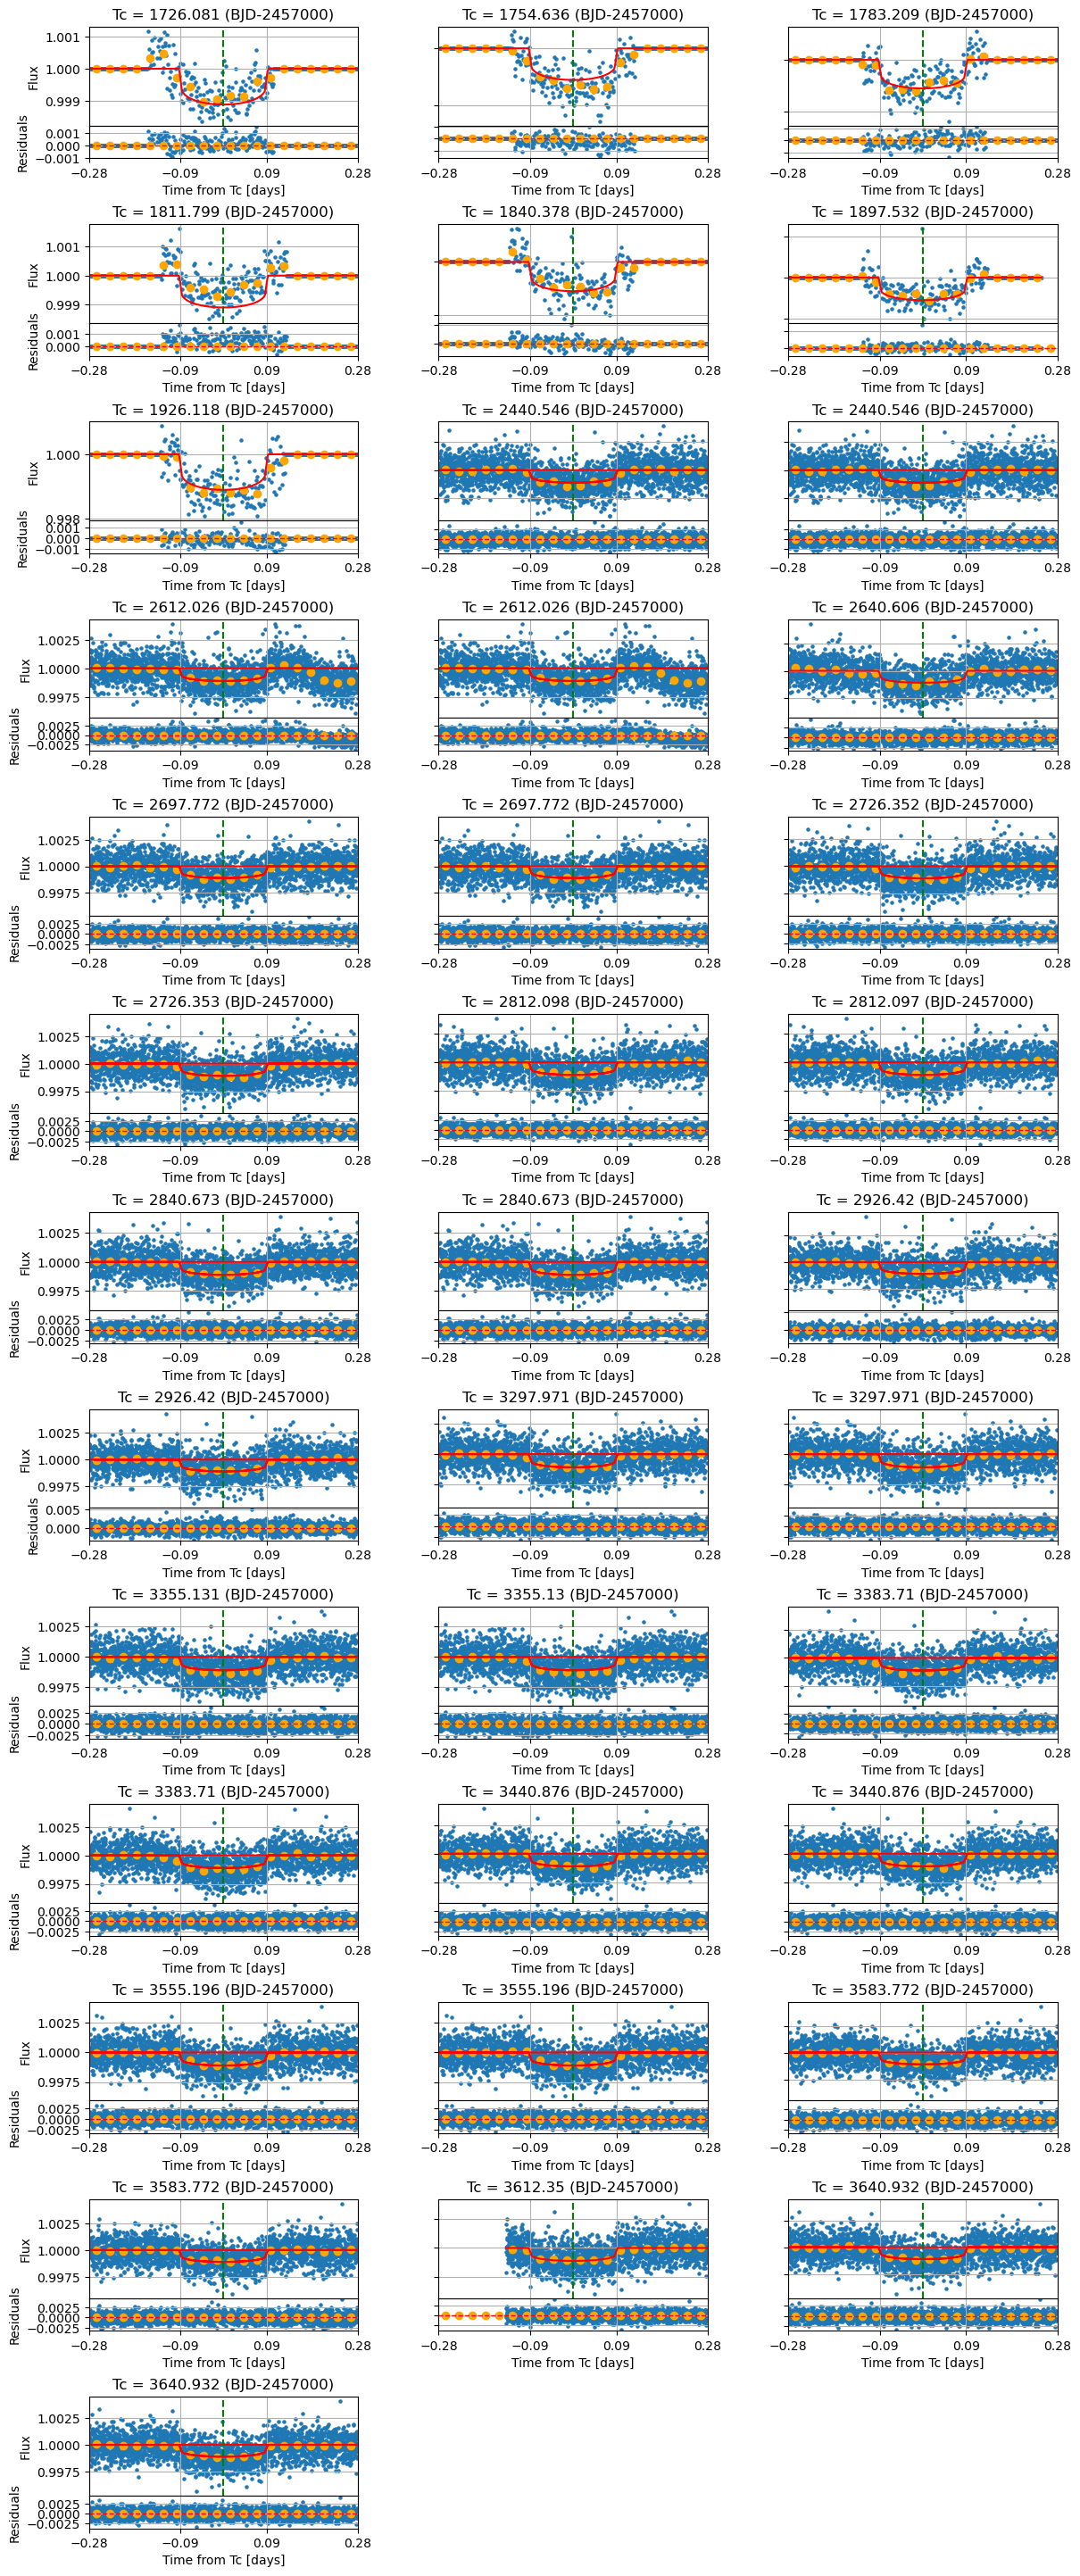

In [340]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

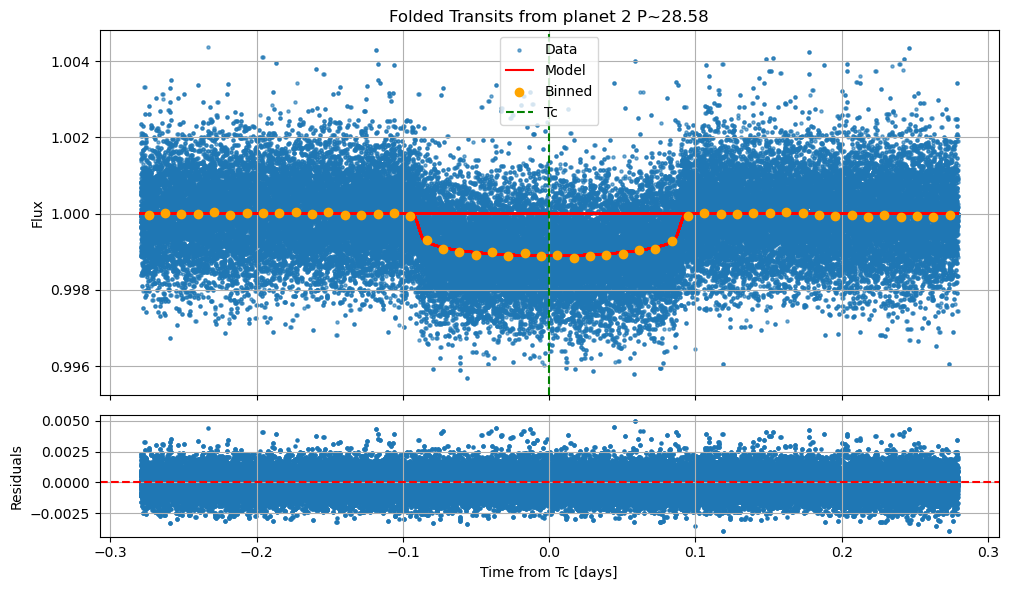

In [341]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 2 P~{round(planet_2_period.value, 3)}')

## PLanet 3

In [342]:
### Planet params (from barros et al 2022)
# planet b
per_3=  38.352562 #38.353037
rp_3=  0.0305954481349672 #0.02916
b_3=  0.323085496752003 #0.440
T14_3= 5.51199861214238 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [343]:
tc_guess_3 = transit_times_3
### get tc ranges for fit
tc_3 = []
for i in range(len(tc_guess_3)):
    start = tc_guess_3[i] - ttv_hour
    end = tc_guess_3[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_3.append(t)

In [344]:
### initialize arrays
tc_chi = np.zeros(len(tc_3))
tc_chi_parabola = np.zeros(len(tc_3))
ttv = np.zeros(len(tc_3))
ttv_p = np.zeros(len(tc_3))
errors = []
errors_p = []
err_tc_chi = []

In [345]:
tc_chi_3, ttv_3, tc_err3 = plot_chi_sq(time, flux, flux_err, tc_3, tc_guess_3, per_3, rp_3, b_3, T14_3, u1, u2)

In [346]:
print(tc_chi_3)

[1743.50678673 1781.90589962 1820.26809213 1896.9572721  1973.66422917
 2433.91581236 2433.91585304 2625.82548853 2664.02365296 2664.02359144
 2702.35403615 2702.35397464 2740.7172484  2740.71739127 2817.40964563
 2817.40958413 2932.462144   2932.46215755 3354.30387705 3354.30401988
 3392.66074868 3392.66102082 3469.46116495 3469.46174366 3546.07301151
 3546.07279358 3584.45171573 3584.45172929 3622.76948764 3622.76916752
 3661.12751981 3661.12745827]


In [347]:
### after inspection of single transits
values_to_remove_3 = [2625.8254885322663, 3469.4611649489834, 3584.45172929]
# Define a tolerance level (adjust if needed)
tolerance = 1e-1

# tc_chi_3 = [x for x in tc_chi_3 if not any(math.isclose(x, val, abs_tol=tolerance) for val in values_to_remove_3)]

# Remove matching entries from both tc_chi_2 and ttv_2
tc_chi_3_cleaned = []
ttv_3_cleaned = []
tc_err_3_cleaned = []

for i in range(len(tc_chi_3)):
    if not any(math.isclose(tc_chi_3[i], val, abs_tol=tolerance) for val in values_to_remove_3):
        tc_chi_3_cleaned.append(tc_chi_3[i])
        ttv_3_cleaned.append(ttv_3[i])
        tc_err_3_cleaned.append(tc_err3[i])

# Overwrite the originals if needed
tc_chi_3 = tc_chi_3_cleaned
ttv_3 = ttv_3_cleaned
tc_err3 = tc_err_3_cleaned


print("Modified List (after removal):", tc_chi_3)


Modified List (after removal): [1743.5067867259972, 1781.9058996213168, 1820.268092127431, 1896.9572720979222, 1973.6642291724381, 2433.91581235986, 2433.915853041328, 2664.023652963715, 2664.0235914374516, 2702.354036146605, 2702.353974638256, 2740.7172483989852, 2740.71739126556, 2817.4096456334382, 2817.40958413121, 2932.462144004524, 2932.462157552539, 3354.303877047129, 3354.304019881324, 3392.660748681723, 3392.6610208230263, 3546.073011508136, 3546.072793583128, 3622.76948764032, 3622.769167524473, 3661.127519810426, 3661.1274582659653]


In [348]:
tc_err_3 = []
for i in range(len(tc_err3)):
    if len(tc_err3[i]) >= 2:  # Check if the element has at least two values
        sig = np.sqrt(tc_err3[i][0]**2 + tc_err3[i][1]**2)
        tc_err_3.append(sig)
    else:
        print(f"Unexpected format in tc_err3[{i}]: {tc_err3[i]}, {tc_chi_3[i]}")

# print(tc_err_3)

In [349]:
# Transit windows
buffer = 1.5 * T14_3
transit_times_3 = tc_chi_3

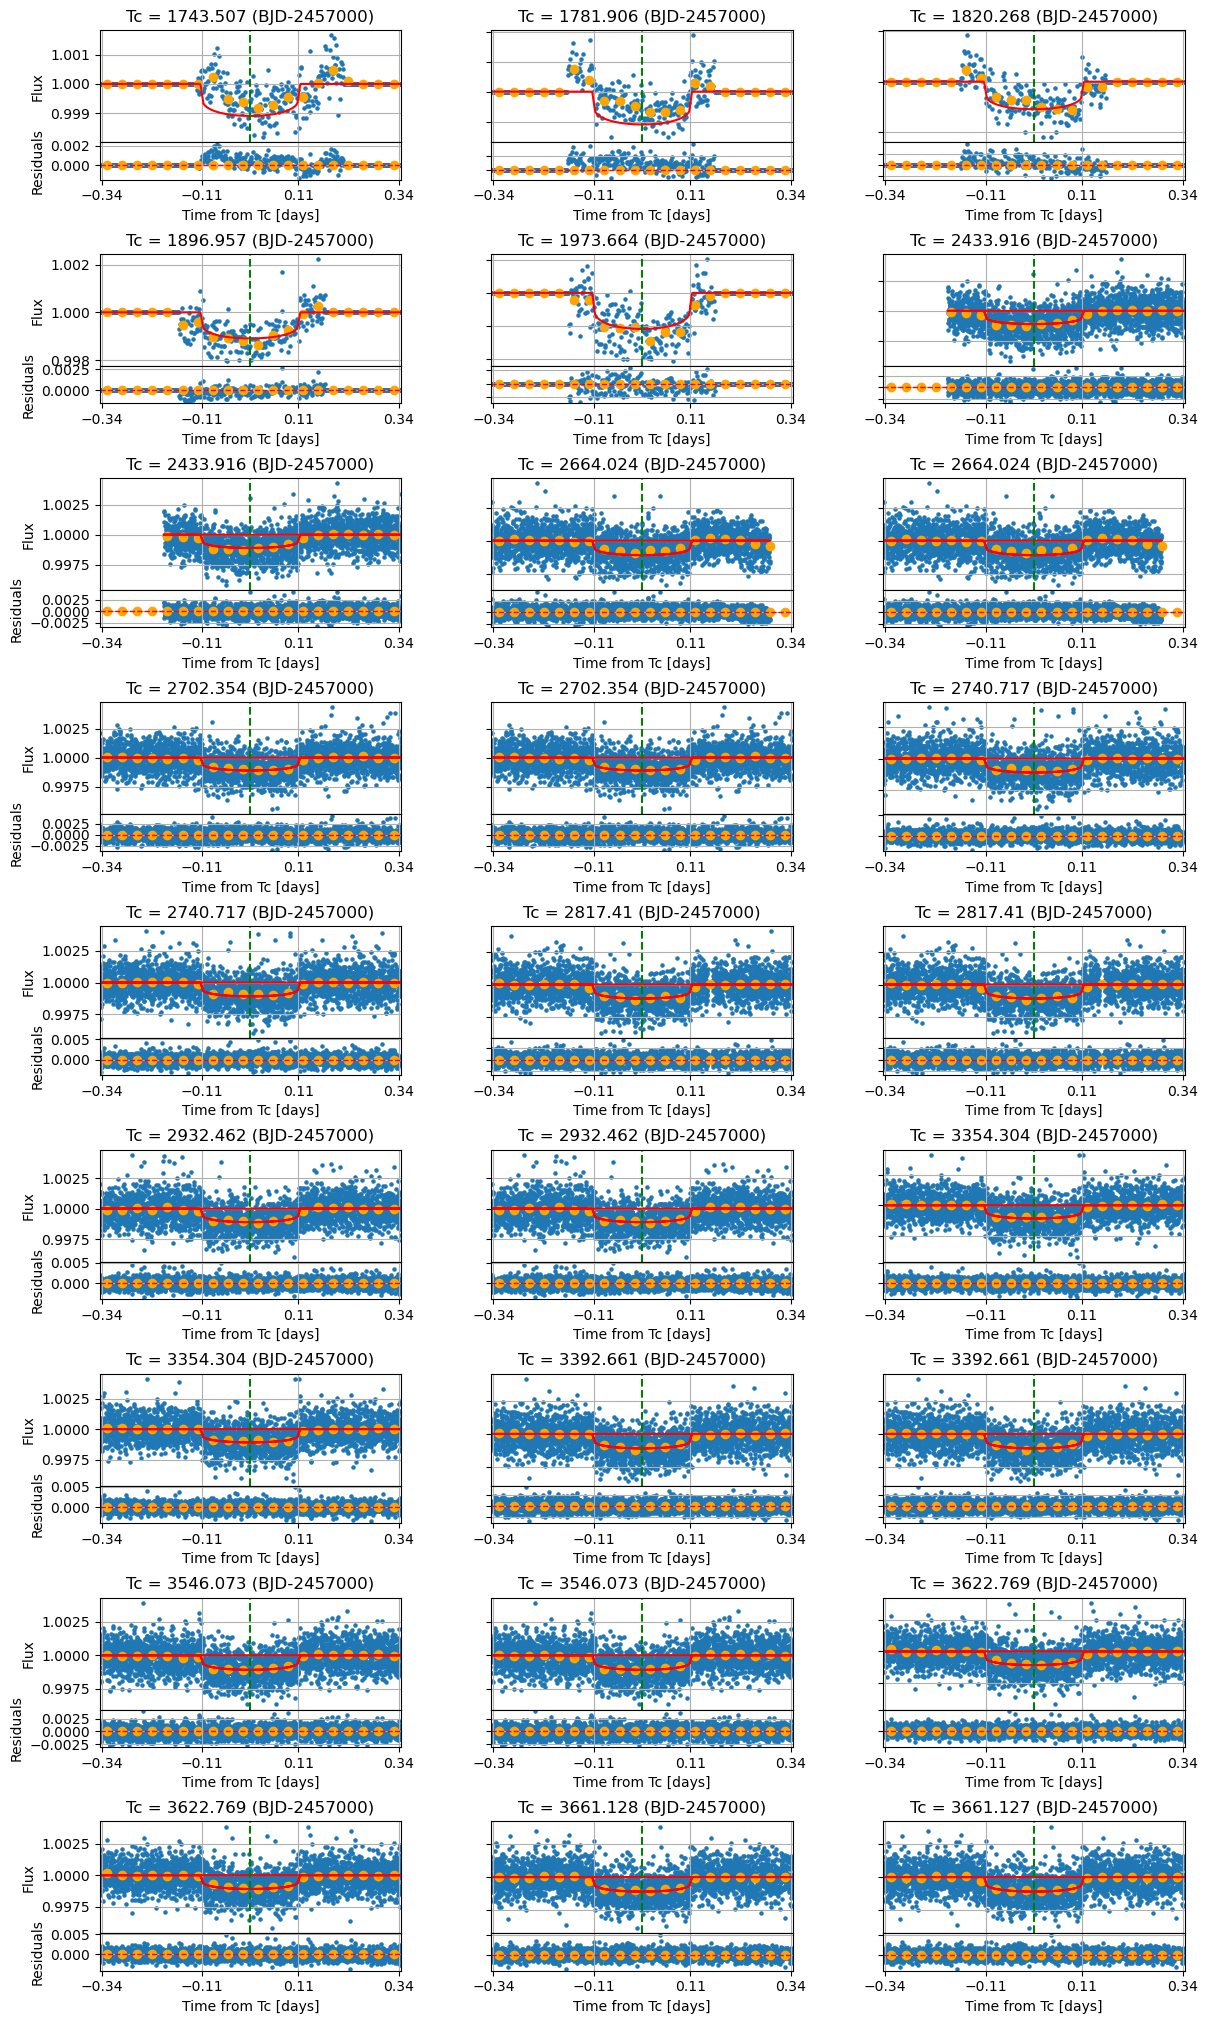

In [350]:
plot_transits(transit_times_3, per_3, rp_3, b_3, T14_3, u1, u2)

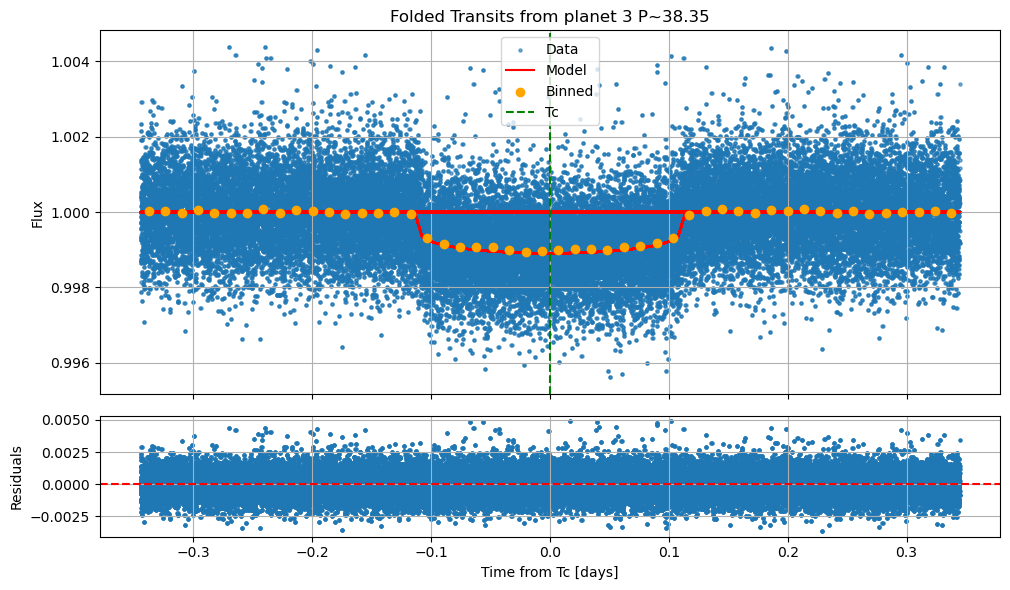

In [351]:
plot_folded_from_transits(transit_times_3, time, flux, per_3, rp_3, b_3, T14_3, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 3 P~{round(planet_3_period.value, 3)}')

In [352]:
# Calculate the indices of transits for each planet
indices_1 = np.round((transit_times_1 - planet_1_t0.value) / planet_1_period.value).astype(int)
indices_2 = np.round((transit_times_2 - planet_2_t0.value) / planet_2_period.value).astype(int)
indices_3 = np.round((transit_times_3 - planet_3_t0.value) / planet_3_period.value).astype(int)


# O-C

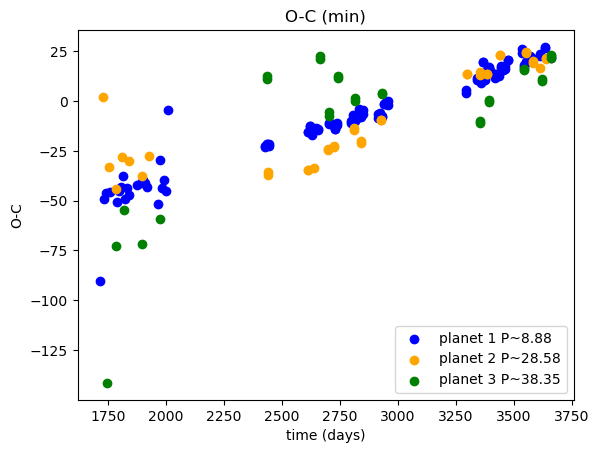

In [353]:
# TTV
ttv_1 = np.array(ttv_1)
ttv_2 = np.array(ttv_2)
ttv_3 = np.array(ttv_3)


plt.scatter(tc_chi_1, ttv_1*(24*60),c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

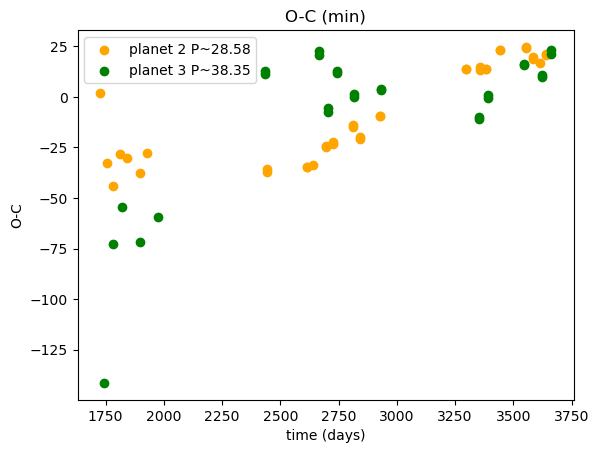

In [354]:
plt.scatter(tc_chi_2, ttv_2*(24*60),c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3*(24*60),c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

[-6.27769863e-03  6.52614314e-02 -7.12116949e+00  3.55581400e-04]
[ 1.21575357e-02  6.00422228e-02  6.29854591e+00 -3.22620831e-04]


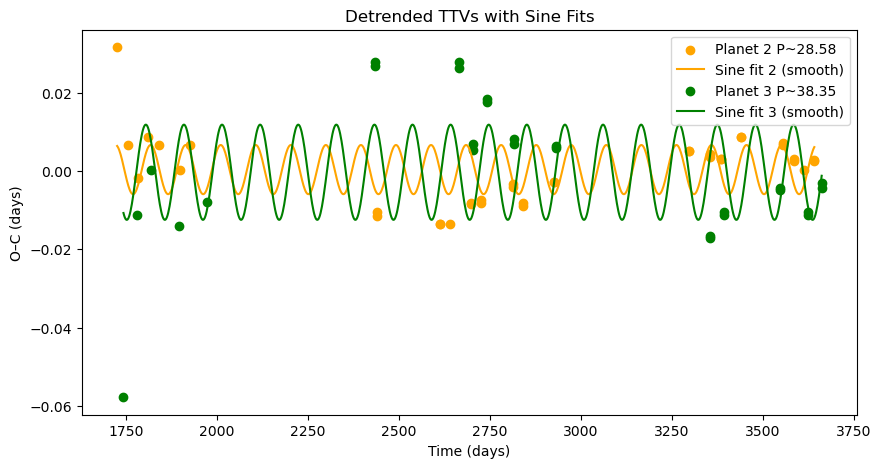

In [355]:
# Fit functions
def linear(x, a, b):
    return a * x + b

def sine(x, A, omega, phase, offset):
    return A * np.sin(omega * x + phase) + offset
# Fit and subtract for planet 2
popt_lin_2, _ = curve_fit(linear, tc_chi_2, ttv_2)
ttv_2_detrended = ttv_2 - linear(np.array(tc_chi_2), *popt_lin_2)

# Fit and subtract for planet 3
popt_lin_3, _ = curve_fit(linear, tc_chi_3, ttv_3)
ttv_3_detrended = ttv_3 - linear(np.array(tc_chi_3), *popt_lin_3)

# Initial guess: amplitude, frequency (rad/day), phase, offset
guess_2 = [0.01, 2 * np.pi / 100, 0, 0]
popt_sin_2, _ = curve_fit(sine, tc_chi_2, ttv_2_detrended, p0=guess_2)
print(popt_sin_2)

guess_3 = [0.03, 2 * np.pi / 100, 0, 0]
popt_sin_3, _ = curve_fit(sine, tc_chi_3, ttv_3_detrended, p0=guess_3)
print(popt_sin_3)

# Dense time arrays for smooth plots
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Detrended fits: only plot sine on linear-subtracted times
sine_fit_2 = sine(dense_time_2, *popt_sin_2)
sine_fit_3 = sine(dense_time_3, *popt_sin_3)

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended, color='orange', label=f'Planet 2 P~{round(planet_2_period.value, 3)}')
plt.plot(dense_time_2, sine_fit_2, 'orange', label='Sine fit 2 (smooth)')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended, color='green', label=f'Planet 3 P~{round(planet_3_period.value, 3)}')
plt.plot(dense_time_3, sine_fit_3, 'g', label='Sine fit 3 (smooth)')

plt.title('Detrended TTVs with Sine Fits')
plt.xlabel('Time (days)')
plt.ylabel('O–C (days)')
plt.legend()
plt.show()

[ 2.04724789e-05 -6.40939721e-02  5.85869644e-03  3.02093014e-02
  6.08087665e+00]
[ 3.47722067e-05 -1.03444015e-01  1.97996051e-02  3.03898321e-02
 -1.66924996e+01]


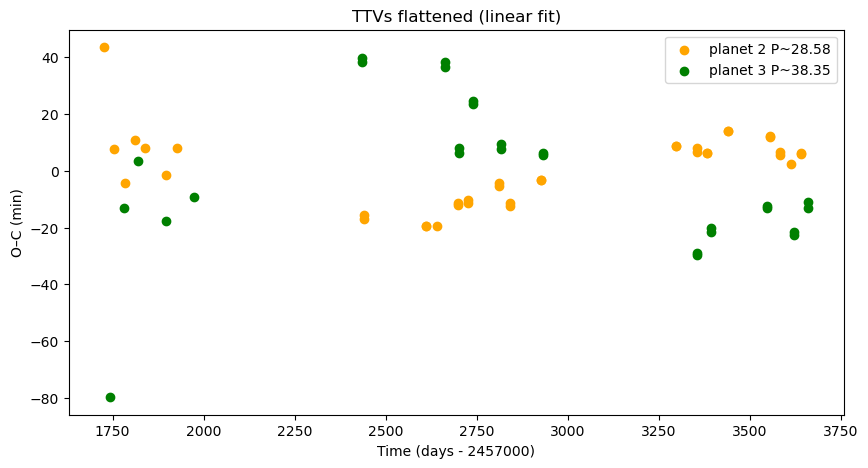

In [358]:
def linear_sine(t, a, b, A, omega, phase):
    return a * t + b + A * np.sin(omega * t + phase)

# Convert TTVs to minutes
ttv_2_min = np.array(ttv_2)
ttv_3_min = np.array(ttv_3) 

# Initial guesses: [slope, intercept, amplitude, omega, phase]
guess_2 = [28, 0, 0.01, 3.26255812e-02, 0]
guess_3 = [38, 0, 0.05, 3.05795071e-02, 0]

# Fit for planet 2
popt_2, _ = curve_fit(linear_sine, tc_chi_2, ttv_2_min, p0=guess_2)

# Fit for planet 3
popt_3, _ = curve_fit(linear_sine, tc_chi_3, ttv_3_min, p0=guess_3)

print(popt_2)
print(popt_3)

def linear_only(t, a, b):
    return a * t + b

ttv_2_detrended = ttv_2_min - linear_only(np.array(tc_chi_2), *popt_2[:2])
ttv_3_detrended = ttv_3_min - linear_only(np.array(tc_chi_3), *popt_3[:2])

# Dense time arrays for smooth curves
dense_time_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
dense_time_3 = np.linspace(min(tc_chi_3), max(tc_chi_3), 1000)

# Full model predictions
fit_2_full = linear_sine(dense_time_2, *popt_2)
fit_3_full = linear_sine(dense_time_3, *popt_3)

# Sine-only on detrended
fit_2_sine = fit_2_full - linear_only(dense_time_2, *popt_2[:2])
fit_3_sine = fit_3_full - linear_only(dense_time_3, *popt_3[:2])

# Plot
plt.figure(figsize=(10, 5))

# Planet 2
plt.scatter(tc_chi_2, ttv_2_detrended*24*60, color='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
# plt.plot(dense_time_2, fit_2_sine, 'orange', label='Sine fit 2')

# Planet 3
plt.scatter(tc_chi_3, ttv_3_detrended*24*60, color='green', label=f'planet 3 P~{round(planet_3_period.value,3)}')
# plt.plot(dense_time_3, fit_3_sine, 'g', label='Sine fit 3')

plt.title('TTVs flattened (linear fit)')
plt.xlabel(f'Time (days - {TESS_offset})')
plt.ylabel('O–C (min)')
plt.legend()
plt.show()

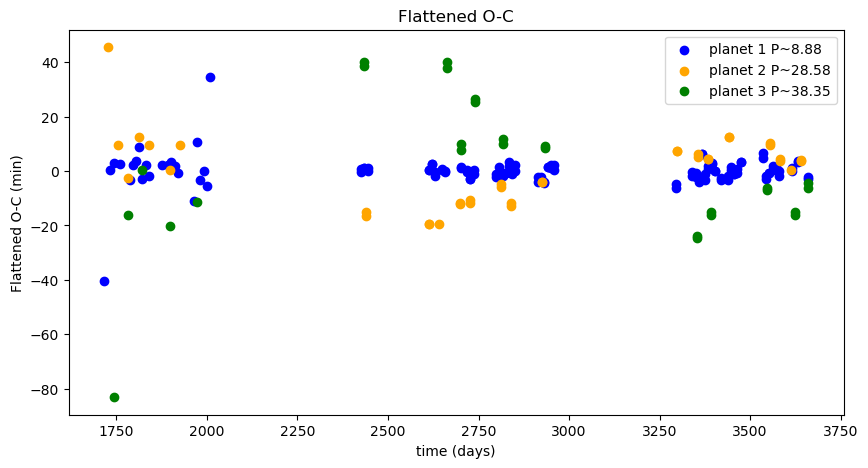

In [359]:
# Fit a linear function to the TTV data
coeffs_1 = np.polyfit(tc_chi_1, ttv_1*(24*60), 1)
linear_fit_1 = np.polyval(coeffs_1, tc_chi_1)

coeffs_2 = np.polyfit(tc_chi_2, ttv_2*(24*60), 1)
linear_fit_2 = np.polyval(coeffs_2, tc_chi_2)

coeffs_3 = np.polyfit(tc_chi_3, ttv_3*(24*60), 1)
linear_fit_3 = np.polyval(coeffs_3, tc_chi_3)

# Subtract the linear fit from the TTV data
ttv_1_detrended = ttv_1*(24*60) - linear_fit_1
ttv_2_detrended = ttv_2*(24*60) - linear_fit_2
ttv_3_detrended = ttv_3*(24*60) - linear_fit_3


plt.figure(figsize=(10, 5))
# Plot the detrended data
plt.scatter(tc_chi_1, ttv_1_detrended,c='b', label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2_detrended,c='orange', label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.scatter(tc_chi_3, ttv_3_detrended,c='g', label=f'planet 3 P~{round(planet_3_period.value,3)}')

plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.legend()
plt.show()

## Multi-harmonic fit

In [360]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [361]:
j = 4 # 4:3 MMR
p_2 = planet_2_period.value
p_3 = planet_3_period.value
tc_2 = planet_2_t0.value
tc_3 = planet_3_t0.value


delta = delta_(p_2, p_3, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_3, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.006401171579743181
TTV period: 1497.7779667265215 days


In [362]:
def ttv_amp_1(P1, m2, m_star, j, delta, f, Z):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z)/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z)/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

In [363]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])


In [364]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [365]:
print(len(indices_2))
print(len(transit_times_2))
print(len(tc_err_2))

37
37
37


In [366]:
from scipy.optimize import least_squares
indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)
indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)

### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 1.72605433e+03  2.85801094e+01  1.18823103e-02  1.74355339e+03
  3.83518927e+01 -2.57247984e-02  2.07316432e+03  8.48662314e+02]


In [367]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, A_bc_err, t_c0_err, P_c_err, A_cb_err, P_cb_err, t_cb0_err = param_errors

In [368]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 1726.05433380 ± 0.00221390
   P_b = 28.58010939 ± 0.00005541
  A_bc = 0.01188231 ± 0.00113161
  t_c0 = 1743.55338686 ± 0.00494622
   P_c = 38.35189275 ± 0.00016851
  A_cb = -0.02572480 ± 0.00244353
  P_cb = 2073.16431584 ± 107.08171667
 t_cb0 = 848.66231445 ± 109.94633976


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_1356/3052238240.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


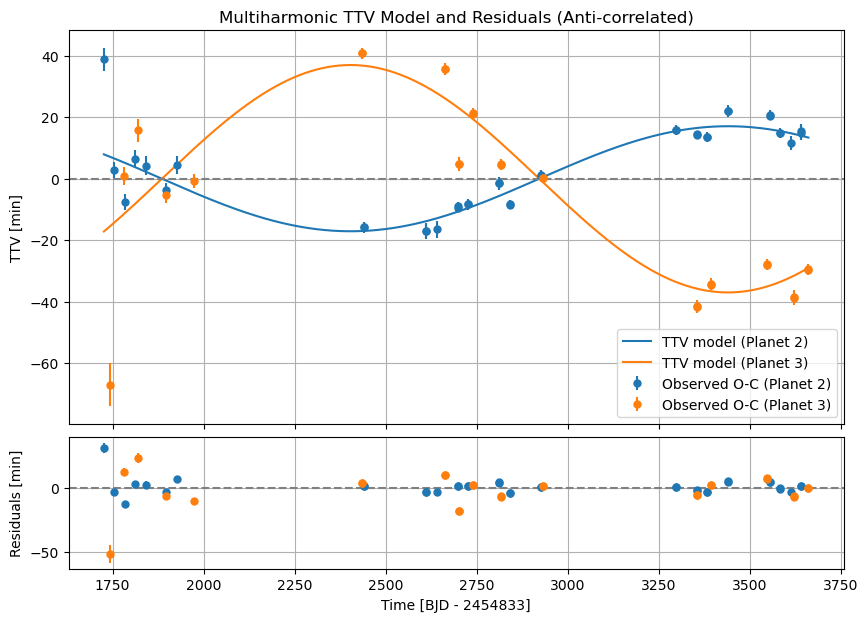

In [369]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# Combine observed times to set the time range
all_times = np.concatenate([transit_times_2, transit_times_3])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) * 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) * 1440  # <- NEGATE here

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)

# Observed O-C residuals in minutes
oc_b = (np.array(transit_times_2) - t_lin_obs_b) * 1440
oc_c = (np.array(transit_times_3) - t_lin_obs_c) * 1440


# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) * 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) * 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet 2)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet 3)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(tc_err_2)*1440, fmt='o',
             color='tab:blue', label='Observed O-C (Planet 2)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(tc_err_3)*1440, fmt='o',
             color='tab:orange', label='Observed O-C (Planet 3)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [min]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(tc_err_2)*1440, fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(tc_err_3)*1440, fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [min]")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [370]:
print('Predicted values from Lubin et al 2022:')
print('predicted P_23: 1490 ± 10 days')
print('predicted A_23: 15.5 ± 9.1 min')
print('predicted A_32: 59.2 ± 13.8 min')
print('Multi-harmonic fit values:')
print(f'P_23: {np.round(P_cb,6)} ± {np.round(P_cb_err,6)} days')
print(f'A_23: {np.round(A_bc,6)*1440} ± {np.round(A_bc_err,6)*1440} min')
print(f'A_32: {np.round(A_cb,6)*1440} ± {np.round(A_cb_err,6)*1440} min')

Predicted values from Lubin et al 2022:
predicted P_23: 1490 ± 10 days
predicted A_23: 15.5 ± 9.1 min
predicted A_32: 59.2 ± 13.8 min
Multi-harmonic fit values:
P_23: 2073.164316 ± 107.081717 days
A_23: 17.11008 ± 1.63008 min
A_32: -37.044000000000004 ± 3.51936 min


In [ ]:
# import pickle

# # Bundle all relevant data into a dictionary
# ttv_data = {
#     "tc_lin_obs_2": t_lin_obs_b,
#     "tc_lin_obs_3": t_lin_obs_c,
#     "omc_2": oc_b,
#     "omc_3": oc_c,
#     "ttv_model_2": ttv_model_b,
#     "ttv_model_3": ttv_model_c,
#     "residuals_2": residuals_b,
#     "residuals_3": residuals_c,
#     "tc_err_2": np.array(tc_err_2),
#     "tc_err_3": np.array(tc_err_3),
#     "indices_2": np.array(indices_2),
#     "indices_3": np.array(indices_3)
# }

# # Save to a file
# with open("1339_data.pkl", "wb") as f:
#     pickle.dump(ttv_data, f)
